# Intro to Embeddings Data Camp

In [5]:
!uv pip install sentence-transformers scikit-learn matplotlib numpy

Using Python 3.13.5 environment at: /Users/brooksjohnson/bbc_data_science/.venv
Audited 4 packages in 16ms


In [9]:
### Abstracts from three data science domains
papers = [
    # Machine Learning Papers
    {
        'title': 'Building Your First Neural Network with PyTorch',
        'abstract': '''Learn how to construct and train a neural network from scratch using PyTorch. This paper covers the fundamentals of defining layers, activation functions, and forward propagation. You'll build a multi-layer perceptron for classification tasks, understand backpropagation, and implement gradient descent optimization. By the end, you'll have a working model that achieves over 90% accuracy on the MNIST dataset.'''
    },
    {
        'title': 'Preventing Overfitting: Regularization Techniques Explained',
        'abstract': '''Overfitting is one of the most common challenges in machine learning. This guide explores practical regularization methods including L1 and L2 regularization, dropout layers, and early stopping. You'll learn how to detect overfitting by monitoring training and validation loss, implement regularization in both scikit-learn and TensorFlow, and tune regularization hyperparameters to improve model generalization on unseen data.'''
    },
    {
        'title': 'Hyperparameter Tuning with Grid Search and Random Search',
        'abstract': '''Selecting optimal hyperparameters can dramatically improve model performance. This paper demonstrates systematic approaches to hyperparameter optimization using grid search and random search. You'll learn how to define hyperparameter spaces, implement cross-validation during tuning, and use scikit-learn's GridSearchCV and RandomizedSearchCV. We'll compare both methods and discuss when to use each approach for efficient model optimization.'''
    },
    {
        'title': 'Transfer Learning: Using Pre-trained Models for Image Classification',
        'abstract': '''Transfer learning lets you leverage pre-trained models to solve new problems with limited data. This paper shows how to use pre-trained convolutional neural networks like ResNet and VGG for custom image classification tasks. You'll learn how to freeze layers, fine-tune network weights, and adapt pre-trained models to your specific domain. We'll build a classifier that achieves high accuracy with just a few hundred training images.'''
    },

    # Data Engineering/ETL Papers
    {
        'title': 'Handling Missing Data: Strategies and Best Practices',
        'abstract': '''Missing data can derail your analysis if not handled properly. This comprehensive guide covers detection methods for missing values, statistical techniques for understanding missingness patterns, and practical imputation strategies. You'll learn when to use mean imputation, forward fill, and more sophisticated approaches like KNN imputation. We'll work through real datasets with missing values and implement robust solutions using pandas.'''
    },
    {
        'title': 'Data Validation Techniques for ETL Pipelines',
        'abstract': '''Building reliable data pipelines requires thorough validation at every stage. This paper teaches you how to implement data quality checks, define validation rules, and catch errors before they propagate downstream. You'll learn schema validation, outlier detection, and referential integrity checks. We'll build a validation framework using Great Expectations and integrate it into an automated ETL workflow for production data systems.'''
    },
    {
        'title': 'Cleaning Messy CSV Files: A Practical Guide',
        'abstract': '''Real-world CSV files are rarely clean and analysis-ready. This hands-on paper walks through common data quality issues: inconsistent formatting, duplicate records, invalid entries, and encoding problems. You'll master pandas techniques for standardizing column names, removing duplicates, handling date parsing errors, and dealing with mixed data types. We'll transform a messy CSV with multiple quality issues into a clean dataset ready for analysis.'''
    },
    {
        'title': 'Building Scalable ETL Workflows with Apache Airflow',
        'abstract': '''Apache Airflow helps you build, schedule, and monitor complex data pipelines. This paper introduces Airflow's core concepts including DAGs, operators, and task dependencies. You'll learn how to define pipeline workflows, implement retry logic and error handling, and schedule jobs for automated execution. We'll build a complete ETL pipeline that extracts data from APIs, transforms it, and loads it into a data warehouse on a daily schedule.'''
    },

    # Data Visualization Papers
    {
        'title': 'Creating Interactive Dashboards with Plotly Dash',
        'abstract': '''Interactive dashboards make data exploration intuitive and engaging. This paper teaches you how to build web-based dashboards using Plotly Dash. You'll learn to create interactive charts with dropdowns, sliders, and date pickers, implement callbacks for dynamic updates, and design responsive layouts. We'll build a complete dashboard for exploring sales data with filters, multiple chart types, and real-time updates.'''
    },
    {
        'title': 'Matplotlib Best Practices: Making Publication-Quality Plots',
        'abstract': '''Creating clear, professional visualizations requires attention to design principles. This guide covers matplotlib best practices for publication-quality plots. You'll learn about color palette selection, font sizing and typography, axis formatting, and legend placement. We'll explore techniques for reducing chart clutter, choosing appropriate chart types, and creating consistent styling across multiple plots for research papers and presentations.'''
    },
    {
        'title': 'Data Storytelling: Designing Effective Visualizations',
        'abstract': '''Good visualizations tell a story and guide viewers to insights. This paper focuses on the principles of visual storytelling and effective chart design. You'll learn how to choose the right visualization for your data, apply pre-attentive attributes to highlight key information, and structure narratives through sequential visualizations. We'll analyze both effective and ineffective visualizations, discussing what makes certain design choices successful.'''
    },
    {
        'title': 'Building Real-Time Visualization Streams with Bokeh',
        'abstract': '''Visualizing streaming data requires specialized techniques and tools. This paper demonstrates how to create real-time updating visualizations using Bokeh. You'll learn to implement streaming data sources, update plots dynamically as new data arrives, and optimize performance for continuous updates. We'll build a live monitoring dashboard that displays streaming sensor data with smoothly updating line charts and real-time statistics.'''
    }
]

print(f"Loaded {len(papers)} paper abstracts")
print(f"Topics covered: Machine Learning, Data Engineering, and Data Visualization")

Loaded 12 paper abstracts
Topics covered: Machine Learning, Data Engineering, and Data Visualization


In [12]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

abstracts = [paper['abstract'] for paper in papers]
embeddings = model.encode(abstracts)

### Let's examine what we've created
print(f"Shape of embeddings: {embeddings.shape}")
print(f"Each abstract is represented by a vector of {embeddings.shape[1]} numbers")
print(f"\nFirst few values of the first embedding:")
print(embeddings[0][:10])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8134.62it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of embeddings: (12, 384)
Each abstract is represented by a vector of 384 numbers

First few values of the first embedding:
[-0.06071803 -0.13064861  0.00328697 -0.04209434 -0.03220845  0.02034254
  0.00421564 -0.01300784 -0.10266113 -0.04565623]


In [13]:
### Let's look at one paper and its embedding
print("Paper title:", papers[0]['title'])
print("\nAbstract:", papers[0]['abstract'][:100] + "...")
print("\nEmbedding shape:", embeddings[0].shape)
print("Embedding type:", type(embeddings[0]))

Paper title: Building Your First Neural Network with PyTorch

Abstract: Learn how to construct and train a neural network from scratch using PyTorch. This paper covers the ...

Embedding shape: (384,)
Embedding type: <class 'numpy.ndarray'>


In [14]:
## Use PCA to capture the most important information
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print(f"Original embedding dimensions: {embeddings.shape[1]}")
print(f"Reduced embedding dimensions: {embeddings_2d.shape[1]}")
print(f"\nVariance explained by these 2 dimensions: {pca.explained_variance_ratio_.sum():.2%}")


Original embedding dimensions: 384
Reduced embedding dimensions: 2

Variance explained by these 2 dimensions: 41.20%


## Understanding Our Topics
See how the 12 papers are organized by topic. This will help us understand the patterns in the embeddings


In [15]:
### Print papers grouped by topic
print("=" * 80)
print("PAPER REFERENCE GUIDE")
print("=" * 80)

topics = [
    ("Machine Learning", list(range(0, 4))),
    ("Data Engineering/ETL", list(range(4, 8))),
    ("Data Visualization", list(range(8, 12)))
]

for topic_name, indices in topics:
    print(f"\n{topic_name}:")
    print("-" * 80)
    for idx in indices:
        print(f"  Paper {idx+1}: {papers[idx]['title']}")

PAPER REFERENCE GUIDE

Machine Learning:
--------------------------------------------------------------------------------
  Paper 1: Building Your First Neural Network with PyTorch
  Paper 2: Preventing Overfitting: Regularization Techniques Explained
  Paper 3: Hyperparameter Tuning with Grid Search and Random Search
  Paper 4: Transfer Learning: Using Pre-trained Models for Image Classification

Data Engineering/ETL:
--------------------------------------------------------------------------------
  Paper 5: Handling Missing Data: Strategies and Best Practices
  Paper 6: Data Validation Techniques for ETL Pipelines
  Paper 7: Cleaning Messy CSV Files: A Practical Guide
  Paper 8: Building Scalable ETL Workflows with Apache Airflow

Data Visualization:
--------------------------------------------------------------------------------
  Paper 9: Creating Interactive Dashboards with Plotly Dash
  Paper 10: Matplotlib Best Practices: Making Publication-Quality Plots
  Paper 11: Data Storyte

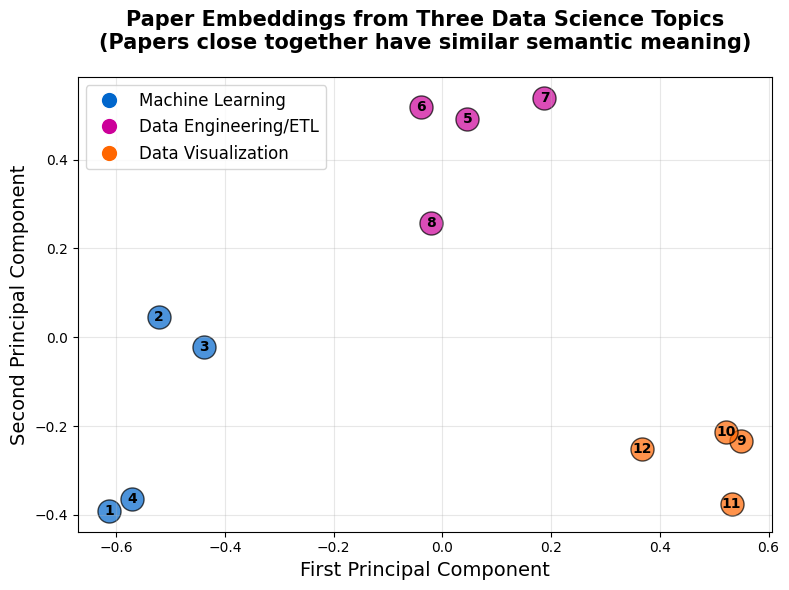

In [16]:
import matplotlib.pyplot as plt
import numpy as np

### Create the visualization
plt.figure(figsize=(8, 6))

### Define colors for different topics
colors = ['#0066CC', '#CC0099', '#FF6600']
categories = ['Machine Learning', 'Data Engineering/ETL', 'Data Visualization']

### Create color mapping for each paper
color_map = []
for i in range(12):
    if i < 4:
        color_map.append(colors[0])  # Machine Learning
    elif i < 8:
        color_map.append(colors[1])  # Data Engineering
    else:
        color_map.append(colors[2])  # Data Visualization

### Plot each paper
for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, c=color_map[i], s=275, alpha=0.7, edgecolors='black', linewidth=1)
    # Add paper numbers as labels
    plt.annotate(str(i+1), (x, y), fontsize=10, fontweight='bold',
                ha='center', va='center')

plt.xlabel('First Principal Component', fontsize=14)
plt.ylabel('Second Principal Component', fontsize=14)
plt.title('Paper Embeddings from Three Data Science Topics\n(Papers close together have similar semantic meaning)',
          fontsize=15, fontweight='bold', pad=20)

### Add a legend showing which colors represent which topics
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors[i], markersize=12,
                              label=categories[i]) for i in range(len(categories))]
plt.legend(handles=legend_elements, loc='best', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()